In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'

In [ ]:
c, _, _, _, _ = load_and_unify_data('/content/extracted_coordinates_x_b_noVec.csv', '/content/extracted_coordinates_y_b_noVec.csv')

✓ SPP file loaded with 7973 rows.
✓ Kinematic file loaded with 7910 rows.


In [ ]:
c

,GPST,x_x,y_x,z_x,ns,sdx(m),sdy(m),sdz(m),vx(m/s),vy(m/s),vz(m/s),x_y,y_y,z_y,diff_x,diff_y,diff_z
0,2024-02-14 04:19:28,461332.1582,5.634451e+06,2.945941e+06,13.0,3.5287,11.2818,6.9751,0.00394,0.01413,-0.01400,461329.8229,5.634439e+06,2.945930e+06,-2.3353,-11.9833,-11.1453
1,2024-02-14 04:19:29,461332.0927,5.634452e+06,2.945941e+06,13.0,3.5287,11.2825,6.9752,-0.01285,-0.07268,-0.01953,461329.8225,5.634439e+06,2.945930e+06,-2.2702,-12.0702,-11.3839
2,2024-02-14 04:19:30,461332.1570,5.634452e+06,2.945941e+06,13.0,3.5287,11.2832,6.9753,0.01059,0.00316,-0.00138,461329.8234,5.634439e+06,2.945930e+06,-2.3336,-12.1444,-11.2149
3,2024-02-14 04:19:31,461332.1452,5.634451e+06,2.945941e+06,13.0,3.5287,11.2839,6.9755,0.00565,-0.02572,-0.02712,461329.8237,5.634439e+06,2.945930e+06,-2.3215,-11.8067,-11.1306
4,2024-02-14 04:19:32,461332.2278,5.634451e+06,2.945940e+06,13.0,3.5287,11.2846,6.9756,-0.00935,0.04126,0.02129,461329.8229,5.634439e+06,2.945930e+06,-2.4049,-11.5746,-10.9527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7905,2024-02-14 06:32:16,464118.3633,5.632637e+06,2.949008e+06,12.0,6.0019,21.8718,8.2883,0.70386,-1.01379,1.73050,464115.5768,5.632630e+06,2.948996e+06,-2.7865,-6.2407,-11.6303
7906,2024-02-14 06:32:17,464119.3652,5.632636e+06,2.949009e+06,11.0,10.7919,30.4155,11.5919,1.33650,-1.13444,1.68668,464120.9077,5.632624e+06,2.948997e+06,1.5425,-12.2113,-12.3875
7907,2024-02-14 06:32:18,464120.3386,5.632635e+06,2.949011e+06,11.0,10.7929,30.4123,11.5914,1.08636,0.16246,1.98146,464112.4989,5.632624e+06,2.949003e+06,-7.8397,-11.4952,-8.3335
7908,2024-02-14 06:32:19,464122.0149,5.632634e+06,2.949013e+06,11.0,10.7938,30.4091,11.5910,1.99354,-1.73132,1.09637,464113.8278,5.632623e+06,2.949004e+06,-8.1871,-11.3048,-8.2500


In [ ]:
c[['diff_x','diff_y','diff_z']].describe()

,diff_x,diff_y,diff_z
count,7910.000000,7910.000000,7910.000000
mean,-1.544412,-11.607630,-10.268504
std,2.183539,8.741975,3.148556
min,-17.801200,-92.033700,-47.289900
25%,-2.646650,-13.932600,-11.308500
50%,-1.675250,-10.202300,-9.622200
75%,-0.595925,-7.123900,-8.535350
max,36.715500,27.580000,2.672600


In [ ]:
dx = np.array(c['diff_x'])
dy = np.array(c['diff_y'])
dz = np.array(c['diff_z'])

In [ ]:
np.mean(np.sqrt((dx**2) + (dy**2) + (dz**2)))

np.float64(16.257782583959923)

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings('ignore')

In [2]:
# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'

In [3]:
# --- 2. MODEL TRAINING AND EVALUATION ---



def train_ensemble_and_evaluate(unified_df, feature_cols, n_networks=3, add_tree=False):
    # --- Data prep ---
    ## Same as train_and_evaluate ========================================================================================
    X = unified_df[feature_cols]
    y = unified_df[['diff_x', 'diff_y', 'diff_z']]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)
    y_test_scaled = y_scaler.transform(y_test)

    # --- Define NN builder ---
    def build_model(seed):
        tf.keras.utils.set_random_seed(seed)
        inputs = layers.Input(shape=(X_train_scaled.shape[1],))
        x = layers.Dense(128, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        x1 = layers.Dense(64, activation='relu')(x)
        x1 = layers.BatchNormalization()(x1)
        x1 = layers.Dropout(0.3)(x1)

        x = layers.Concatenate()([x, x1])
        x = layers.Dense(32, activation='relu')(x)
        outputs = layers.Dense(3)(x)
        model = models.Model(inputs, outputs)

        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
        model.compile(optimizer=optimizer, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
        return model
    ## Same as train_and_evaluate =========================================================================================================

    # --- Train multiple NNs ---
    models_list = []
    histories = []
    for i in range(n_networks):
        print(f"\n{'='*80}\nTraining Neural Net #{i+1}/{n_networks}\n{'='*80}")
        model = build_model(seed=42+i) # seed should be different for having different results in NN
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
        # very important for adjusting learning_rate
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, verbose=1, min_lr=1e-6)

        history = model.fit(
            X_train_scaled, y_train_scaled,
            validation_split=0.2,
            epochs=500,
            batch_size=32,
            verbose=1,
            callbacks=[early_stop, reduce_lr]
        )

        models_list.append(model)
        histories.append(history)# history is after fitting the model

    # --- Average ensemble predictions for NN---
    preds_scaled = np.zeros_like(y_test_scaled)
    for model in models_list:
        preds_scaled += model.predict(X_test_scaled)
    preds_scaled /= n_networks

    y_pred = y_scaler.inverse_transform(preds_scaled)
    y_test_vals = y_test.values

    # --- Optional: Add tree model (hybrid ensemble) ---
    if add_tree:
        try:
            from sklearn.ensemble import RandomForestRegressor
            print("\nTraining hybrid XGBoost regressor on NN residuals (train split)...")

            # Predict on training data to compute residuals
            preds_train_scaled = np.zeros_like(y_train_scaled)
            for model in models_list:
                preds_train_scaled += model.predict(X_train_scaled) # preds_train_scaled -> y_train_pred predicted
            preds_train_scaled /= n_networks
            y_train_pred = y_scaler.inverse_transform(preds_train_scaled)
            y_train_vals = y_train.values  # y_train_actual

            residuals_train = y_train_vals - y_train_pred # calculate the difference between  (y_train_actual - y_train_pred) the output is what NN missing in it's predictions.

            # Fit the tree model on training residuals
            tree_model = RandomForestRegressor(
                n_estimators=200,
                max_depth=20,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            ) # the XGBRegressor is trying to predict the errors caused by NN
            tree_model.fit(X_train_scaled, residuals_train)

            # Apply correction on test predictions
            tree_pred = tree_model.predict(X_test_scaled)
            y_pred += tree_pred 
        except ImportError:
            print("XGBoost not installed — skipping hybrid stage.")

    # --- Evaluation ---
    print("\n" + "="*80 + "\nFINAL EVALUATION: ENSEMBLE MODEL\n" + "="*80)
    per_axis_rmse = []
    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(f"--- Axis {axis} ---\n  R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n  RMSE (m): {rmse:.4f}\n")

    overall_rmse = np.mean(per_axis_rmse)
    print(f"Overall mean RMSE (m): {overall_rmse:.4f}")

    # --- Plot learning curves for first model ---
    plt.figure(figsize=(6,4))
    plt.plot(histories[0].history['loss'], label='Train Loss (Model 1)')
    plt.plot(histories[0].history['val_loss'], label='Val Loss (Model 1)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return models_list, x_scaler, y_scaler, X_test, y_pred

In [28]:
# --- 3. ACCURACY IMPROVEMENT ANALYSIS ---

def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints the before-and-after 3D error comparison."""
    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # Original 3D Error
    original_3d_errors = np.sqrt(test_df['diff_x']**2 + test_df['diff_y']**2 + test_df['diff_z']**2)
    mean_original_error = original_3d_errors.median()

    # Corrected 3D Error
    corrected_spp_x = test_df[spp_x_col] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred_corrected[:, 2]

    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(corrected_diff_x**2 + corrected_diff_y**2 + corrected_diff_z**2)
    mean_corrected_error = corrected_3d_errors.median()

    improvement = mean_original_error - mean_corrected_error
    improvement_percent = (improvement / mean_original_error) * 100 if mean_original_error != 0 else 0

    print("\n" + "="*80 + "\nMODEL ACCURACY IMPROVEMENT ANALYSIS\n" + "="*80)
    print(f"Mean 3D Error (Original): {mean_original_error:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_error:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")

In [29]:


# --- 5. MAIN EXECUTION ---

spp_filepath = r'F:\zizo\RTKCorrection\src\research\extracted_coordinates_x_b_IONO.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\extracted_coordinates_y_b_IONO.csv'
    # 1) step is to return merged data
unified_df, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)





✓ SPP file loaded with 7962 rows.
✓ Kinematic file loaded with 7910 rows.


In [30]:
unified_df['diff_y'].describe()

count    7910.000000
mean      -12.212414
std         7.309231
min       -89.124000
25%       -14.494500
50%       -10.834850
75%        -8.796850
max        41.849300
Name: diff_y, dtype: float64

In [ ]:
print(f"Number of rows where diff_y > -20: {len(unified_df[unified_df['diff_y'] > -20])}")
print(f"Number of rows where diff_y < 20: {len(unified_df[unified_df['diff_y'] < 20])}")
print(f"Number of rows where -20 < diff_y < 20: {len(unified_df[(unified_df['diff_y'] > -20) & (unified_df['diff_y'] < 20)])}")
print("end","===="*50)
print(f"Number of rows where diff_y > -20: {len(unified_df[unified_df['diff_x'] > -20])}")
print(f"Number of rows where diff_y < 20: {len(unified_df[unified_df['diff_x'] < 20])}")
print(f"Number of rows where -20 < diff_y < 20: {len(unified_df[(unified_df['diff_x'] > -20) & (unified_df['diff_x'] < 20)])}")
print("end","===="*50)
print(f"Number of rows where diff_y > -20: {len(unified_df[unified_df['diff_z'] > -20])}")
print(f"Number of rows where diff_y < 20: {len(unified_df[unified_df['diff_z'] < 20])}")
print(f"Number of rows where -20 < diff_y < 20: {len(unified_df[(unified_df['diff_z'] > -20) & (unified_df['diff_z'] < 20)])}")

Number of rows where diff_y > -20: 4642
Number of rows where diff_y < 20: 7902
Number of rows where -20 < diff_y < 20: 4634
end ========================================================================================================================================================================================================
Number of rows where diff_y > -20: 7899
Number of rows where diff_y < 20: 7901
Number of rows where -20 < diff_y < 20: 7890
end ========================================================================================================================================================================================================
Number of rows where diff_y > -20: 6970
Number of rows where diff_y < 20: 7910
Number of rows where -20 < diff_y < 20: 6970


In [22]:
# Filter rows where diff_y is between -20 and 20
unified_df = unified_df[(unified_df['diff_y'] > -20) & (unified_df['diff_y'] < 20)]
print(f"Total number of rows in original DataFrame: {len(unified_df)}")
print(f"Number of rows where -20 < diff_y < 20: {len(unified_df)}")
print("\nFirst few rows of the filtered DataFrame:")
print(unified_df.head())

# Update the unified_df to only include the filtered rows
unified_df = unified_df.copy()
print(f"\nDataFrame now contains only rows where diff_y is between -20 and 20 ({len(unified_df)} rows)")

Total number of rows in original DataFrame: 7480
Number of rows where -20 < diff_y < 20: 7480

First few rows of the filtered DataFrame:
                 GPST          x_x           y_x           z_x    ns  sdx(m)  \
0 2024-02-14 04:19:28  461332.1561  5.634451e+06  2.945941e+06  13.0  2.1526   
1 2024-02-14 04:19:29  461332.0907  5.634452e+06  2.945941e+06  13.0  2.1526   
2 2024-02-14 04:19:30  461332.1550  5.634452e+06  2.945941e+06  13.0  2.1526   
3 2024-02-14 04:19:31  461332.1431  5.634451e+06  2.945941e+06  13.0  2.1526   
4 2024-02-14 04:19:32  461332.2257  5.634451e+06  2.945940e+06  13.0  2.1526   

   sdy(m)  sdz(m)  vx(m/s)  vy(m/s)  vz(m/s)          x_y           y_y  \
0  6.8830  4.2543  0.00394  0.01413 -0.01400  461329.7861  5.634437e+06   
1  6.8835  4.2544 -0.01285 -0.07268 -0.01953  461329.7854  5.634437e+06   
2  6.8839  4.2544  0.01059  0.00316 -0.00138  461329.7862  5.634437e+06   
3  6.8843  4.2545  0.00565 -0.02572 -0.02712  461329.7872  5.634437e+06   
4  6.88

In [24]:
print(f"Number of rows where diff_y > -20: {len(unified_df[unified_df['diff_y'] > -20])}")
print(f"Number of rows where diff_y < 20: {len(unified_df[unified_df['diff_y'] < 20])}")
print(f"Number of rows where -20 < diff_y < 20: {len(unified_df[(unified_df['diff_y'] > -20) & (unified_df['diff_y'] < 20)])}")
print("end","===="*50)
print(f"Number of rows where diff_x > -20: {len(unified_df[unified_df['diff_x'] > -20])}")
print(f"Number of rows where diff_x < 20: {len(unified_df[unified_df['diff_x'] < 20])}")
print(f"Number of rows where -20 < diff_x < 20: {len(unified_df[(unified_df['diff_x'] > -20) & (unified_df['diff_x'] < 20)])}")
print("end","===="*50)
print(f"Number of rows where diff_z > -20: {len(unified_df[unified_df['diff_z'] > -20])}")
print(f"Number of rows where diff_z < 20: {len(unified_df[unified_df['diff_z'] < 20])}")
print(f"Number of rows where -20 < diff_z < 20: {len(unified_df[(unified_df['diff_z'] > -20) & (unified_df['diff_z'] < 20)])}")

Number of rows where diff_y > -20: 7480
Number of rows where diff_y < 20: 7480
Number of rows where -20 < diff_y < 20: 7480
end ========================================================================================================================================================================================================
Number of rows where diff_x > -20: 7480
Number of rows where diff_x < 20: 7480
Number of rows where -20 < diff_x < 20: 7480
end ========================================================================================================================================================================================================
Number of rows where diff_z > -20: 7467
Number of rows where diff_z < 20: 7480
Number of rows where -20 < diff_z < 20: 7467


In [25]:
# Filter rows where diff_y is between -20 and 20
unified_df = unified_df[(unified_df['diff_z'] > -20) & (unified_df['diff_z'] < 20)]
print(f"Total number of rows in original DataFrame: {len(unified_df)}")
print(f"Number of rows where -20 < diff_y < 20: {len(unified_df)}")
print("\nFirst few rows of the filtered DataFrame:")
print(unified_df.head())

# Update the unified_df to only include the filtered rows
unified_df = unified_df.copy()
print(f"\nDataFrame now contains only rows where diff_y is between -20 and 20 ({len(unified_df)} rows)")

Total number of rows in original DataFrame: 7467
Number of rows where -20 < diff_y < 20: 7467

First few rows of the filtered DataFrame:
                 GPST          x_x           y_x           z_x    ns  sdx(m)  \
0 2024-02-14 04:19:28  461332.1561  5.634451e+06  2.945941e+06  13.0  2.1526   
1 2024-02-14 04:19:29  461332.0907  5.634452e+06  2.945941e+06  13.0  2.1526   
2 2024-02-14 04:19:30  461332.1550  5.634452e+06  2.945941e+06  13.0  2.1526   
3 2024-02-14 04:19:31  461332.1431  5.634451e+06  2.945941e+06  13.0  2.1526   
4 2024-02-14 04:19:32  461332.2257  5.634451e+06  2.945940e+06  13.0  2.1526   

   sdy(m)  sdz(m)  vx(m/s)  vy(m/s)  vz(m/s)          x_y           y_y  \
0  6.8830  4.2543  0.00394  0.01413 -0.01400  461329.7861  5.634437e+06   
1  6.8835  4.2544 -0.01285 -0.07268 -0.01953  461329.7854  5.634437e+06   
2  6.8839  4.2544  0.01059  0.00316 -0.00138  461329.7862  5.634437e+06   
3  6.8843  4.2545  0.00565 -0.02572 -0.02712  461329.7872  5.634437e+06   
4  6.88

In [26]:
print(f"Number of rows where diff_y > -20: {len(unified_df[unified_df['diff_y'] > -20])}")
print(f"Number of rows where diff_y < 20: {len(unified_df[unified_df['diff_y'] < 20])}")
print(f"Number of rows where -20 < diff_y < 20: {len(unified_df[(unified_df['diff_y'] > -20) & (unified_df['diff_y'] < 20)])}")
print("end","===="*50)
print(f"Number of rows where diff_x > -20: {len(unified_df[unified_df['diff_x'] > -20])}")
print(f"Number of rows where diff_x < 20: {len(unified_df[unified_df['diff_x'] < 20])}")
print(f"Number of rows where -20 < diff_x < 20: {len(unified_df[(unified_df['diff_x'] > -20) & (unified_df['diff_x'] < 20)])}")
print("end","===="*50)
print(f"Number of rows where diff_z > -20: {len(unified_df[unified_df['diff_z'] > -20])}")
print(f"Number of rows where diff_z < 20: {len(unified_df[unified_df['diff_z'] < 20])}")
print(f"Number of rows where -20 < diff_z < 20: {len(unified_df[(unified_df['diff_z'] > -20) & (unified_df['diff_z'] < 20)])}")

Number of rows where diff_y > -20: 7467
Number of rows where diff_y < 20: 7467
Number of rows where -20 < diff_y < 20: 7467
end ========================================================================================================================================================================================================
Number of rows where diff_x > -20: 7467
Number of rows where diff_x < 20: 7467
Number of rows where -20 < diff_x < 20: 7467
end ========================================================================================================================================================================================================
Number of rows where diff_z > -20: 7467
Number of rows where diff_z < 20: 7467
Number of rows where -20 < diff_z < 20: 7467



Training Neural Net #1/3
Epoch 1/500
Epoch 1/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.2577 - rmse: 1.1215 - val_loss: 0.7822 - val_rmse: 0.8844 - learning_rate: 0.0010
Epoch 2/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.2577 - rmse: 1.1215 - val_loss: 0.7822 - val_rmse: 0.8844 - learning_rate: 0.0010
Epoch 2/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7366 - rmse: 0.8583 - val_loss: 0.6205 - val_rmse: 0.7877 - learning_rate: 0.0010
Epoch 3/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7366 - rmse: 0.8583 - val_loss: 0.6205 - val_rmse: 0.7877 - learning_rate: 0.0010
Epoch 3/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6427 - rmse: 0.8017 - val_loss: 0.5400 - val_rmse: 0.7349 - learning_rate: 0.0010
Epoch 4/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6427 - rmse: 0.8017 - val_loss: 0.5400 - val_rmse: 0.7349 - learning_rate: 0.0010
Epoch 4/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5962 - rmse: 0.7721 - val_los

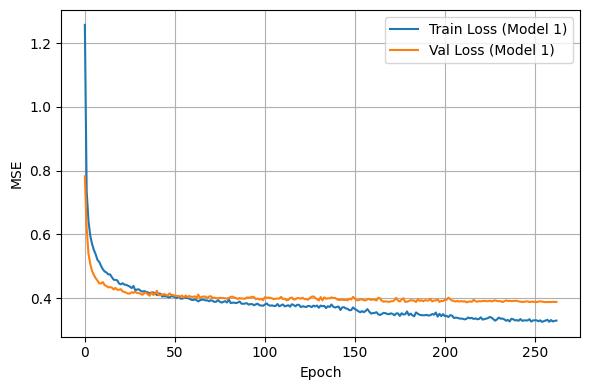


MODEL ACCURACY IMPROVEMENT ANALYSIS
Mean 3D Error (Original): 14.9891 m
Mean 3D Error (Corrected): 1.5044 m

Improvement: 13.4846 m (89.96%)


'\njoblib.dump(best_models, \'best_gnss_model.joblib\')\njoblib.dump(x_scaler, \'x_scaler.joblib\')\njoblib.dump(y_scaler, \'y_scaler.joblib\')\njoblib.dump(feature_cols, \'feature_cols.joblib\')\nprint("\n✓ Best model, scaler, and feature list saved successfully!")\nprint("\n✓ Analysis complete!")'

In [27]:
    # 2) train simple Neural Network (BatchNorm + Dropout)
    # Think of it like asking multiple experts for their opinion and averaging their answers.
best_models, x_scaler, y_scaler, X_test, y_pred = train_ensemble_and_evaluate(unified_df, feature_cols, n_networks=3, add_tree=True)
test_df = unified_df.loc[X_test.index]

calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))
"""
    joblib.dump(best_models, 'best_gnss_model.joblib')
    joblib.dump(x_scaler, 'x_scaler.joblib')
    joblib.dump(y_scaler, 'y_scaler.joblib')
    joblib.dump(feature_cols, 'feature_cols.joblib')
    print("\n✓ Best model, scaler, and feature list saved successfully!")
    print("\n✓ Analysis complete!")"""

above is the data with iono correction

# **Plotting**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

# ====================================================
# 1. LOAD DATA
# ====================================================
spp_path = r"F:\zizo\RTKCorrection\src\research\extracted_coordinates_x_b_IONO.csv"
kin_path = r"F:\zizo\RTKCorrection\src\research\extracted_coordinates_y_b_IONO.csv"

spp_df = pd.read_csv(spp_path)
kin_df = pd.read_csv(kin_path)

# ====================================================
# 2. MERGE BY GPST (EXACT TO SECOND)
# ====================================================
spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

c = pd.merge(spp_df, kin_df, how='inner', on='GPST')
unified_df = c.copy()

print(f"✓ SPP file loaded with {len(spp_df)} rows.")
print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
print(f"✓ Data aligned with {len(unified_df)} rows (inner join on GPST).")

# ====================================================
# 3. CLEAN COLUMN NAMES (to avoid saving errors)
# ====================================================
def clean_column_name(name):
    name = re.sub(r'[^A-Za-z0-9_]+', '_', name)
    return name.strip('_')

unified_df.columns = [clean_column_name(c) for c in unified_df.columns]

# ====================================================
# 4. CREATE OUTPUT DIRECTORY
# ====================================================
out_dir = "analysis_outputs"
os.makedirs(out_dir, exist_ok=True)

# ====================================================
# 5. DIFFERENCE COLUMNS (if applicable)
# ====================================================
# Detect coordinate columns (commonly x, y, z)
x_cols = [c for c in unified_df.columns if re.search(r'x', c, re.IGNORECASE)]
y_cols = [c for c in unified_df.columns if re.search(r'y', c, re.IGNORECASE)]
z_cols = [c for c in unified_df.columns if re.search(r'z', c, re.IGNORECASE)]

# Create difference columns for known coordinate pairs
if 'x_x' in unified_df.columns and 'x_y' in unified_df.columns:
    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
if 'y_x' in unified_df.columns and 'y_y' in unified_df.columns:
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
if 'z_x' in unified_df.columns and 'z_y' in unified_df.columns:
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

# ====================================================
# 6. DESCRIPTIVE STATISTICS
# ====================================================
desc_stats = unified_df.describe().T
desc_stats.to_csv(f"{out_dir}/descriptive_statistics.csv")
print("✓ Descriptive statistics saved.")

# ====================================================
# 7. VISUALIZATION FUNCTIONS
# ====================================================

def plot_distributions(df, out_dir):
    """Plot distributions for all numeric columns."""
    for col in df.columns:
        if col == 'GPST' or not np.issubdtype(df[col].dtype, np.number):
            continue
        plt.figure(figsize=(8,5))
        sns.histplot(df[col], kde=True, bins=50)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(f"{out_dir}/dist_{col}.png")
        plt.close()

def plot_boxplots(df, out_dir):
    """Plot boxplots for all numeric columns."""
    for col in df.columns:
        if col == 'GPST' or not np.issubdtype(df[col].dtype, np.number):
            continue
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.savefig(f"{out_dir}/box_{col}.png")
        plt.close()

def plot_time_series(df, out_dir):
    """Plot time series for all numeric columns."""
    for col in df.columns:
        if col == 'GPST' or not np.issubdtype(df[col].dtype, np.number):
            continue
        plt.figure(figsize=(10,5))
        plt.plot(df['GPST'], df[col], linewidth=1)
        plt.title(f'Time Series of {col}')
        plt.xlabel('GPST')
        plt.ylabel(col)
        plt.tight_layout()
        plt.savefig(f"{out_dir}/time_{col}.png")
        plt.close()

def plot_differences(df, out_dir):
    """Plot histograms and time series of diff_x, diff_y, diff_z."""
    diff_cols = [c for c in df.columns if c.startswith('diff_')]
    for col in diff_cols:
        plt.figure(figsize=(8,5))
        sns.histplot(df[col], kde=True, bins=50, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(f"{out_dir}/diff_dist_{col}.png")
        plt.close()

        plt.figure(figsize=(10,5))
        plt.plot(df['GPST'], df[col], linewidth=1, color='green')
        plt.title(f'Time Series of {col}')
        plt.xlabel('GPST')
        plt.ylabel(col)
        plt.tight_layout()
        plt.savefig(f"{out_dir}/diff_time_{col}.png")
        plt.close()

# ====================================================
# 8. PLOTTING
# ====================================================
plot_distributions(unified_df, out_dir)
plot_boxplots(unified_df, out_dir)
plot_time_series(unified_df, out_dir)
plot_differences(unified_df, out_dir)

# ====================================================
# 9. CORRELATION HEATMAP
# ====================================================
plt.figure(figsize=(10,8))
corr = unified_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (All Numeric Columns)")
plt.tight_layout()
plt.savefig(f"{out_dir}/correlation_heatmap.png")
plt.close()

print(f"✓ Deep EDA and plots saved to folder: {out_dir}/")


C:\Users\User\AppData\Local\Temp\ipykernel_15556\319465020.py:20: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
C:\Users\User\AppData\Local\Temp\ipykernel_15556\319465020.py:21: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')


✓ SPP file loaded with 7962 rows.
✓ Kinematic file loaded with 7910 rows.
✓ Data aligned with 7910 rows (inner join on GPST).
✓ Descriptive statistics saved.
✓ Deep EDA and plots saved to folder: analysis_outputs/
